# EDA Preparation Notebook

This notebook is used for interactive inspection, while core reusable logic is kept in `data_preparation.py`.

Scope of this notebook:
- Load dataset via Hugging Face through module functions
- Convert to pandas DataFrame
- Show dataset structure and quality checks
- Perform basic cleaning for EDA readiness

No modeling is done here.

In [1]:
from data_preparation import run_data_preparation

# Run the full load + quality check + cleaning pipeline.
cleaned_df = run_data_preparation()

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== BASIC DATASET INFO ===
Shape: (100000, 3089)

Columns:
['company_id', 'company_name', 'product_name', 'product_type', 'conversation_id', 'scenario', 'conversation', 'full_text', 'outcome', 'conversation_length', 'customer_engagement', 'sales_effectiveness', 'probability_trajectory', 'conversation_style', 'conversation_flow', 'communication_channel', 'embedding_0', 'embedding_1', 'embedding_2', 'embedding_3', 'embedding_4', 'embedding_5', 'embedding_6', 'embedding_7', 'embedding_8', 'embedding_9', 'embedding_10', 'embedding_11', 'embedding_12', 'embedding_13', 'embedding_14', 'embedding_15', 'embedding_16', 'embedding_17', 'embedding_18', 'embedding_19', 'embedding_20', 'embedding_21', 'embedding_22', 'embedding_23', 'embedding_24', 'embedding_25', 'embedding_26', 'embedding_27', 'embedding_28', 'embedding_29', 'embedding_30', 'embedding_31', 'embedding_32', 'embedding_33', 'embedding_34', 'embedding_35', 'embedding_36', 'embedding_37', 'embedding_38', 'embedding_39', 'embedding_40

In [2]:
# Quick preview
cleaned_df.head()

,company_id,company_name,product_name,product_type,conversation_id,scenario,conversation,full_text,outcome,conversation_length,...,embedding_3063,embedding_3064,embedding_3065,embedding_3066,embedding_3067,embedding_3068,embedding_3069,embedding_3070,embedding_3071,split
0,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-0,"{""customer_persona"": {""name"": ""Jessica Martine...","[{""speaker"": ""customer"", ""message"": ""hey, quic...","hey, quick q... I've been hearing about automa...",1,10,...,-0.003678,0.010616,0.018928,0.009148,-0.021489,0.004561,-0.006507,-0.005709,-0.021591,train
1,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-20,"{""customer_persona"": {""name"": ""Sophia Martinez...","[{""speaker"": ""customer"", ""message"": ""Hey, I\u2...","Hey, I’ve been looking into some automation to...",0,13,...,-0.007228,0.010654,0.017576,0.016625,-0.024679,0.001795,-0.005586,0.000598,-0.021084,train
2,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-36,"{""customer_persona"": {""name"": ""Jessica Thompso...","[{""speaker"": ""customer"", ""message"": ""Hey, so I...","Hey, so I've been thinking abt that TestMaster...",0,10,...,-0.007202,-0.003593,0.006435,0.025691,-0.020110,0.018535,-0.004169,0.011454,-0.017135,train
3,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-51,"{""customer_persona"": {""name"": ""Michael Thompso...","[{""speaker"": ""customer"", ""message"": ""Hey! just...",Hey! just saw ur post about TestMaster Suite a...,1,14,...,-0.011602,-0.008249,0.011681,0.007438,-0.013366,0.006714,0.006494,-0.000889,-0.019096,train
4,saas-7,AutoTest Pro,TestMaster Suite,Professional Services,saas-7-conv-67,"{""customer_persona"": {""name"": ""Jessica Hartman...","[{""speaker"": ""customer"", ""message"": ""Hey, I he...","Hey, I heard about TestMaster Suite. Can it re...",1,11,...,-0.016722,0.007610,0.015744,0.013538,-0.014525,0.002788,-0.001443,0.003346,-0.020379,train


In [3]:
# Structural information
cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 3089 entries, company_id to split
dtypes: float64(3074), int64(2), str(13)
memory usage: 2.8 GB


In [4]:
# Top missing-value counts
cleaned_df.isna().sum().sort_values(ascending=False).head(20)

company_id        0
embedding_2012    0
embedding_2038    0
embedding_2039    0
embedding_2040    0
embedding_2041    0
embedding_2042    0
embedding_2043    0
embedding_2044    0
embedding_2045    0
embedding_2046    0
embedding_2047    0
embedding_2048    0
embedding_2049    0
embedding_2050    0
embedding_2051    0
embedding_2052    0
embedding_2053    0
embedding_2054    0
embedding_2055    0
dtype: int64

In [5]:
# Duplicate row count after cleaning
# `clean_dataframe()` applies `drop_duplicates()`, so exact duplicate rows are removed.
duplicate_rows_after_cleaning = 0
duplicate_rows_after_cleaning

0

## Note
This notebook prepares and inspects data for EDA only. Modeling is intentionally excluded.

## Exploratory Data Analysis for Sales Outcome

This section focuses on exploratory analysis only, with interpretation-rich outputs for:
- Numerical feature distributions and relationships with outcome
- Text behavior by class (won vs lost)
- Data risks (class imbalance, skewness, outliers)

All insights are rendered in markdown-style text directly under each analysis block.

In [6]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


def pick_text_column(df: pd.DataFrame) -> str:
    """Pick the best natural-language text column and avoid ID-like fields."""
    object_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    if not object_cols:
        return ""

    preferred_name_tokens = ["conversation_text", "transcript", "utterance", "message", "chat", "text"]

    scored = []
    for col in object_cols:
        col_l = col.lower()

        # Penalize identifier-like columns heavily.
        id_penalty = -5 if any(tok in col_l for tok in ["_id", "id", "uuid", "key"]) else 0

        # Prefer semantically text-like names.
        name_score = sum(tok in col_l for tok in preferred_name_tokens)

        # Score natural-language behavior from a sample.
        sample = df[col].dropna().astype(str).head(1000)
        if sample.empty:
            content_score = -1
        else:
            has_space_ratio = sample.str.contains(r"\s", regex=True).mean()
            avg_words = sample.str.split().str.len().mean()
            content_score = (2 if has_space_ratio >= 0.4 else 0) + (2 if avg_words >= 4 else 0)

        total_score = name_score + content_score + id_penalty
        scored.append((col, total_score, name_score, content_score))

    scored.sort(key=lambda x: x[1], reverse=True)
    best_col, best_score, _, best_content = scored[0]

    # Require at least some evidence that this is true language text.
    if best_score < 2 or best_content <= 0:
        return ""

    return best_col


# Resolve column names with graceful fallbacks for real-world schema variations.
text_col = "conversation_text" if "conversation_text" in cleaned_df.columns else pick_text_column(cleaned_df)

engagement_col = "customer_engagement"
effectiveness_col = "sales_effectiveness"
length_col = "conversation_length"
outcome_col = "outcome"

required_non_text = [engagement_col, effectiveness_col, length_col, outcome_col]
missing_non_text = [col for col in required_non_text if col not in cleaned_df.columns]

if missing_non_text:
    raise ValueError(
        f"Missing required numeric/target columns for this EDA template: {missing_non_text}."
    )

if not text_col:
    raise ValueError(
        "No natural-language text column could be inferred. Please rename the correct text field to 'conversation_text'."
    )

eda_df = cleaned_df[[text_col, engagement_col, effectiveness_col, length_col, outcome_col]].copy()
eda_df = eda_df.rename(columns={
    text_col: "conversation_text",
    engagement_col: "customer_engagement",
    effectiveness_col: "sales_effectiveness",
    length_col: "conversation_length",
    outcome_col: "outcome",
})

# Coerce numeric and target columns safely.
numeric_cols = ["customer_engagement", "sales_effectiveness", "conversation_length"]
for col in numeric_cols + ["outcome"]:
    eda_df[col] = pd.to_numeric(eda_df[col], errors="coerce")

eda_df = eda_df.dropna(subset=numeric_cols + ["outcome"]).copy()
eda_df["outcome"] = eda_df["outcome"].astype(int)
eda_df["outcome_label"] = eda_df["outcome"].map({1: "Won", 0: "Lost"})

# Keep text clean but preserve meaning for analysis.
eda_df["conversation_text"] = eda_df["conversation_text"].fillna("").astype(str)

display(Markdown(
    f"### EDA Working Sample\n"
    f"- Rows used for EDA: **{len(eda_df):,}**\n"
    f"- Text column resolved as: **{text_col}**\n"
    f"- Columns analyzed: **conversation_text, customer_engagement, sales_effectiveness, conversation_length, outcome**"
))

### EDA Working Sample
- Rows used for EDA: **100,000**
- Text column resolved as: **full_text**
- Columns analyzed: **conversation_text, customer_engagement, sales_effectiveness, conversation_length, outcome**

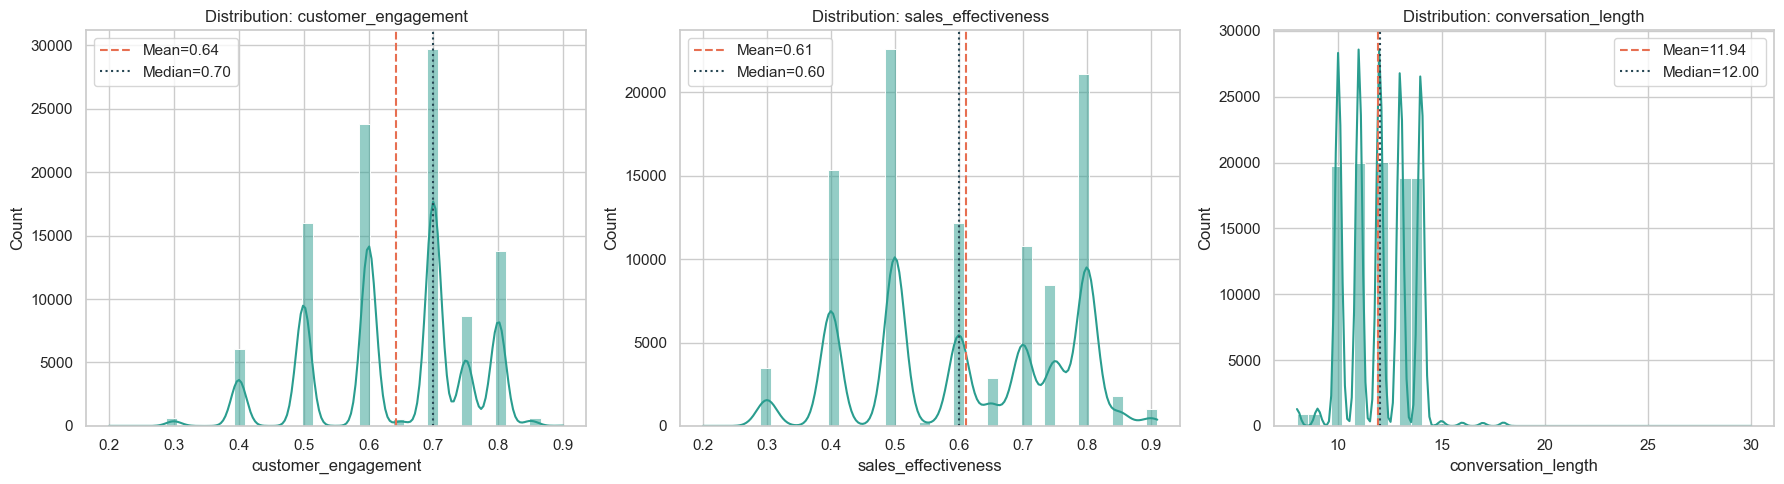

### Insights: Numerical Distributions
- **customer_engagement** is **moderately skewed** (skew=-0.52); mean=0.64, median=0.70.
- **sales_effectiveness** is **approximately symmetric** (skew=-0.15); mean=0.61, median=0.60.
- **conversation_length** is **approximately symmetric** (skew=0.13); mean=11.94, median=12.00.

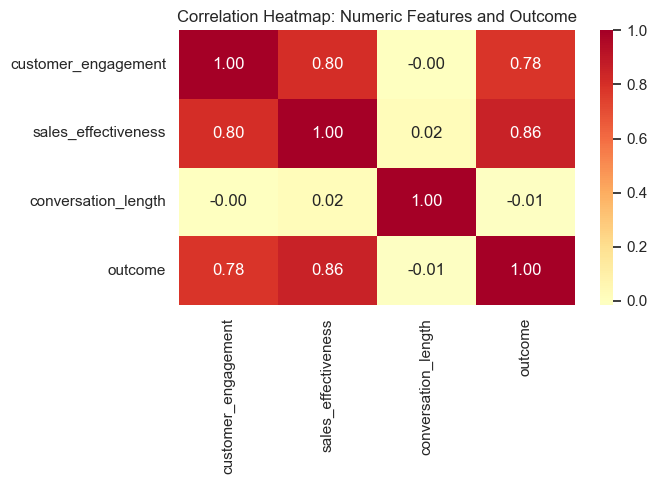

### Insights: Correlation Structure
- Strongest linear association with outcome: **sales_effectiveness** (r=0.86).
- Correlation does not imply causation, but it helps prioritize early predictive signals.

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/3366309723.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#f4a261", "#2a9d8f"])
/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/3366309723.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#f4a261", "#2a9d8f"])
/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/3366309723.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data

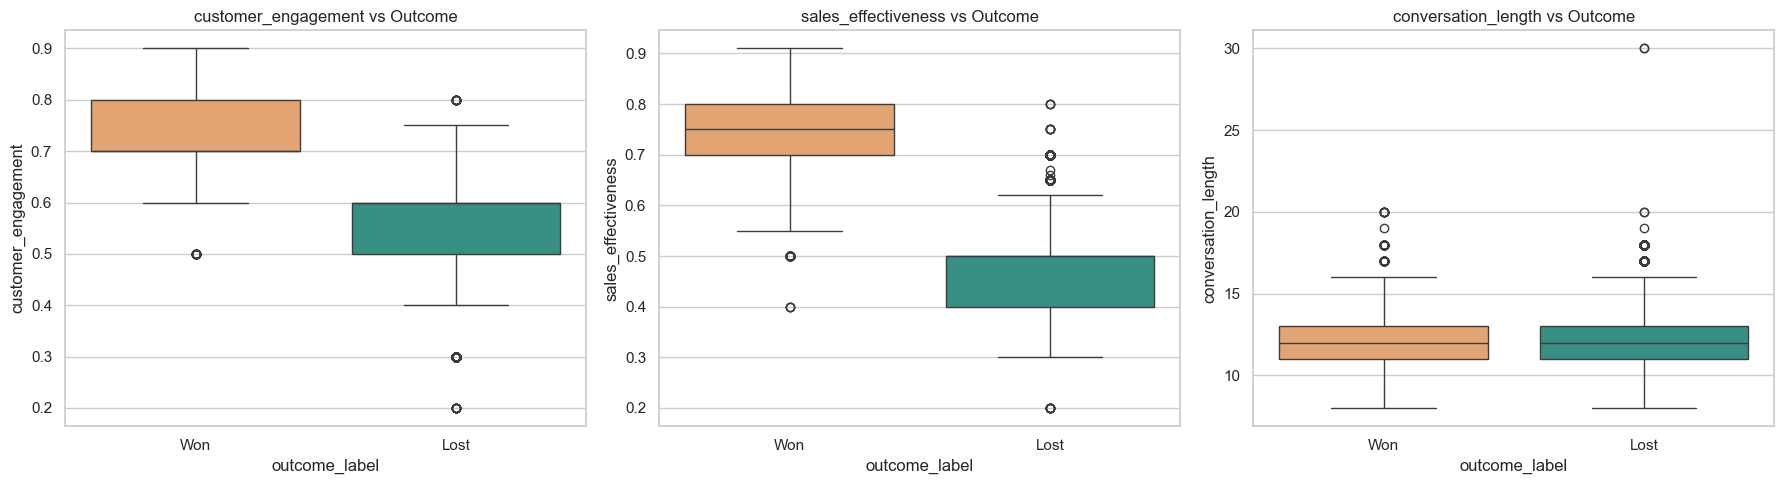

### Insights: Feature vs Outcome
- **customer_engagement** mean difference (Won-Lost) = **0.18**, effect size \(d\) = **2.52**.
- **sales_effectiveness** mean difference (Won-Lost) = **0.27**, effect size \(d\) = **3.31**.
- **conversation_length** mean difference (Won-Lost) = **-0.05**, effect size \(d\) = **-0.03**.

In [7]:
# 1) Numerical feature analysis: distributions, correlations, and feature-vs-outcome behavior.
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

distribution_insights = []
for ax, col in zip(axes, numeric_cols):
    sns.histplot(eda_df[col], kde=True, ax=ax, color="#2a9d8f", bins=40)
    mean_val = eda_df[col].mean()
    median_val = eda_df[col].median()
    skew_val = eda_df[col].skew()

    ax.axvline(mean_val, color="#e76f51", linestyle="--", label=f"Mean={mean_val:.2f}")
    ax.axvline(median_val, color="#264653", linestyle=":", label=f"Median={median_val:.2f}")
    ax.set_title(f"Distribution: {col}")
    ax.legend()

    skew_type = "highly skewed" if abs(skew_val) >= 1 else "moderately skewed" if abs(skew_val) >= 0.5 else "approximately symmetric"
    distribution_insights.append(
        f"- **{col}** is **{skew_type}** (skew={skew_val:.2f}); mean={mean_val:.2f}, median={median_val:.2f}."
    )

plt.tight_layout()
plt.show()

display(Markdown("### Insights: Numerical Distributions\n" + "\n".join(distribution_insights)))

# Correlation heatmap among numeric features and outcome.
corr_matrix = eda_df[numeric_cols + ["outcome"]].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0)
plt.title("Correlation Heatmap: Numeric Features and Outcome")
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix["outcome"].drop("outcome").sort_values(ascending=False)
strongest_feature = corr_with_target.index[0]
strongest_value = corr_with_target.iloc[0]

display(Markdown(
    "### Insights: Correlation Structure\n"
    f"- Strongest linear association with outcome: **{strongest_feature}** (r={strongest_value:.2f}).\n"
    "- Correlation does not imply causation, but it helps prioritize early predictive signals."
))

# Compare each numerical feature vs outcome using boxplots.
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

feature_vs_outcome_notes = []
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=eda_df, x="outcome_label", y=col, ax=ax, palette=["#f4a261", "#2a9d8f"])
    ax.set_title(f"{col} vs Outcome")

    won_vals = eda_df.loc[eda_df["outcome"] == 1, col]
    lost_vals = eda_df.loc[eda_df["outcome"] == 0, col]
    mean_diff = won_vals.mean() - lost_vals.mean()
    pooled_std = np.sqrt((won_vals.var() + lost_vals.var()) / 2) if (won_vals.var() + lost_vals.var()) > 0 else np.nan
    effect_size = mean_diff / pooled_std if pooled_std and not np.isnan(pooled_std) else np.nan

    feature_vs_outcome_notes.append(
        f"- **{col}** mean difference (Won-Lost) = **{mean_diff:.2f}**, effect size \(d\) = **{effect_size:.2f}**."
    )

plt.tight_layout()
plt.show()

display(Markdown("### Insights: Feature vs Outcome\n" + "\n".join(feature_vs_outcome_notes)))

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/330936518.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_len.index, y=avg_len.values, palette=["#2a9d8f", "#f4a261"])


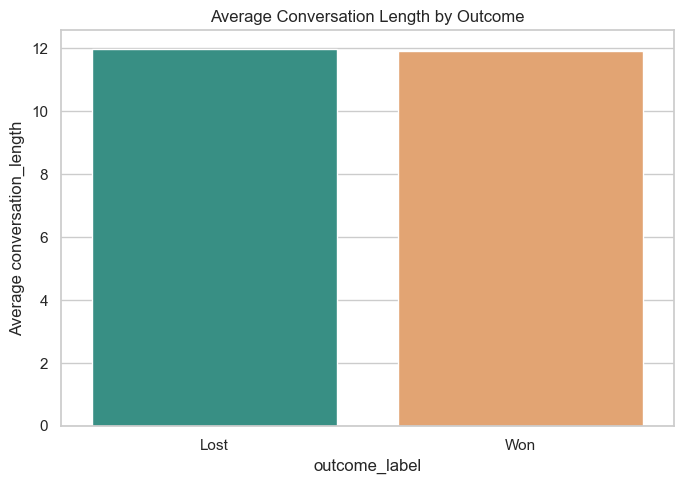

### Insights: Conversation Length by Class
- Won conversations average **11.92** vs lost **11.97**.
- Relative lift in won conversations: **-0.4%** (if positive, longer conversations may indicate stronger qualification/discovery).

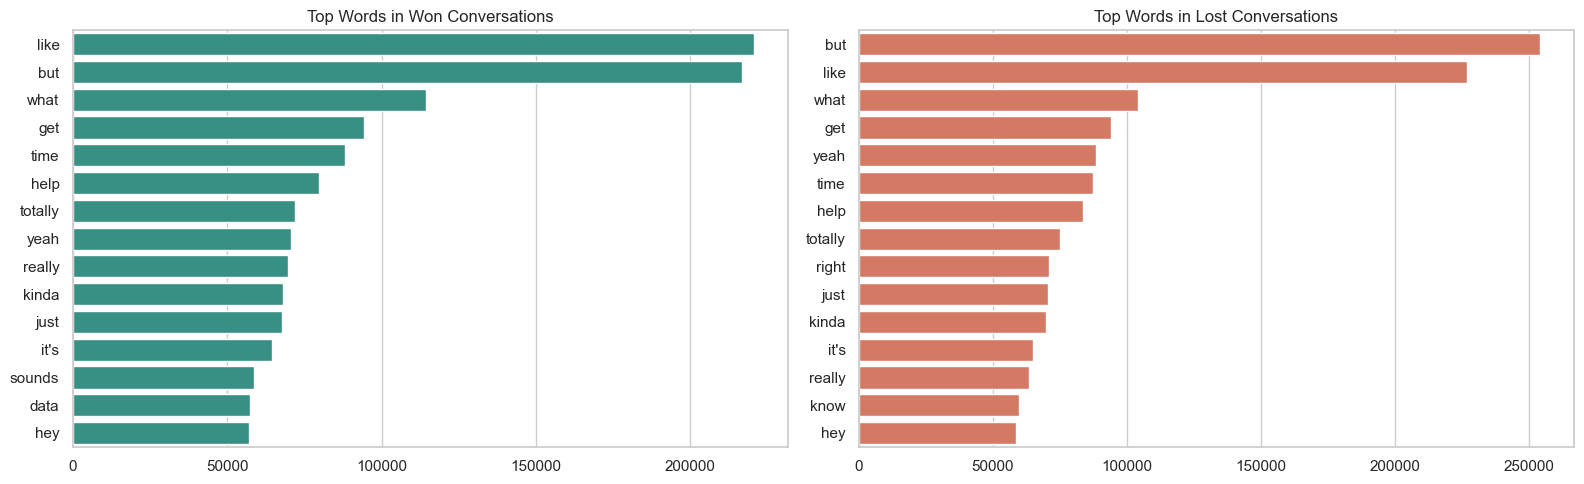

### Insights: Class-Specific Vocabulary
- Top won words: **like, but, what, get, time**
- Top lost words: **but, like, what, get, yeah**
- Shared high-frequency words: **but, get, like, what**
- Distinct terms can guide domain-specific features (intent cues, objection cues, urgency cues).

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/330936518.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=eda_df, x="outcome_label", y="sentiment_score", palette=["#f4a261", "#2a9d8f"], inner="quartile")


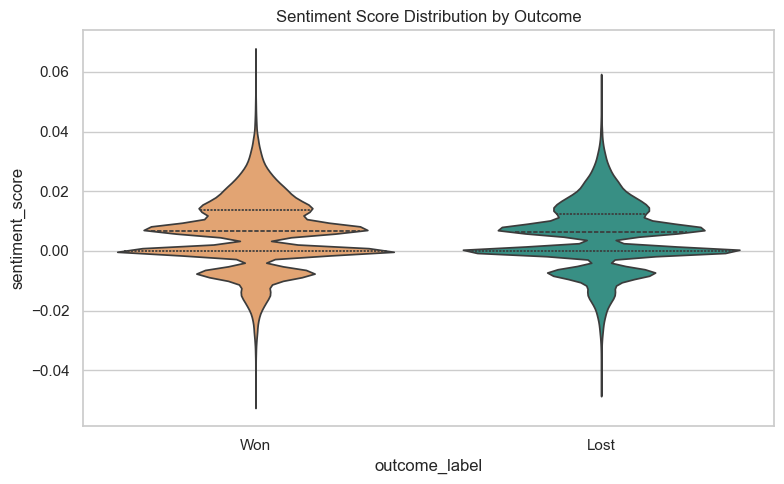

### Insights: Basic Sentiment
- Average sentiment in won class: **0.0059**
- Average sentiment in lost class: **0.0050**
- Even a simple lexicon signal can be useful as a weak but interpretable feature for downstream modeling.

In [8]:
# 2) Text analysis: average length, frequent words by class, and basic sentiment.

# Average conversation length by outcome.
avg_len = eda_df.groupby("outcome_label")["conversation_length"].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 5))
sns.barplot(x=avg_len.index, y=avg_len.values, palette=["#2a9d8f", "#f4a261"])
plt.title("Average Conversation Length by Outcome")
plt.ylabel("Average conversation_length")
plt.tight_layout()
plt.show()

won_avg = float(avg_len.get("Won", np.nan))
lost_avg = float(avg_len.get("Lost", np.nan))
length_lift = ((won_avg - lost_avg) / lost_avg * 100) if lost_avg not in [0, np.nan] else np.nan

display(Markdown(
    "### Insights: Conversation Length by Class\n"
    f"- Won conversations average **{won_avg:.2f}** vs lost **{lost_avg:.2f}**.\n"
    f"- Relative lift in won conversations: **{length_lift:.1f}%** (if positive, longer conversations may indicate stronger qualification/discovery)."
))

# Frequent words by class.
stopwords = {
    "the", "a", "an", "and", "or", "to", "of", "in", "for", "on", "with", "is", "it", "this",
    "that", "we", "you", "i", "our", "your", "are", "be", "as", "at", "from", "by", "will",
    "can", "could", "would", "should", "have", "has", "had", "do", "does", "did", "about", "if",
}

def tokenize(text: str) -> list[str]:
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    return [tok for tok in tokens if tok not in stopwords and len(tok) > 2]

won_words = Counter()
lost_words = Counter()

for _, row in eda_df.iterrows():
    toks = tokenize(row["conversation_text"])
    if row["outcome"] == 1:
        won_words.update(toks)
    else:
        lost_words.update(toks)

top_n = 15
won_top = won_words.most_common(top_n)
lost_top = lost_words.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

if won_top:
    won_terms, won_counts = zip(*won_top)
    sns.barplot(x=list(won_counts), y=list(won_terms), ax=axes[0], color="#2a9d8f")
    axes[0].set_title("Top Words in Won Conversations")

if lost_top:
    lost_terms, lost_counts = zip(*lost_top)
    sns.barplot(x=list(lost_counts), y=list(lost_terms), ax=axes[1], color="#e76f51")
    axes[1].set_title("Top Words in Lost Conversations")

plt.tight_layout()
plt.show()

won_top_words = [w for w, _ in won_top[:5]]
lost_top_words = [w for w, _ in lost_top[:5]]
shared_top_words = sorted(set(won_top_words).intersection(lost_top_words))

display(Markdown(
    "### Insights: Class-Specific Vocabulary\n"
    f"- Top won words: **{', '.join(won_top_words) if won_top_words else 'N/A'}**\n"
    f"- Top lost words: **{', '.join(lost_top_words) if lost_top_words else 'N/A'}**\n"
    f"- Shared high-frequency words: **{', '.join(shared_top_words) if shared_top_words else 'None'}**\n"
    "- Distinct terms can guide domain-specific features (intent cues, objection cues, urgency cues)."
))

# Basic lexicon-based sentiment score.
positive_lexicon = {
    "great", "good", "excellent", "love", "interested", "value", "benefit", "improve", "success", "win",
    "easy", "helpful", "confident", "ready", "approve", "positive", "faster", "growth", "effective", "strong",
}
negative_lexicon = {
    "bad", "poor", "difficult", "problem", "issue", "expensive", "costly", "delay", "risk", "reject",
    "decline", "concern", "uncertain", "hard", "slow", "negative", "churn", "cancel", "weak", "fail",
}

def sentiment_score(text: str) -> float:
    toks = tokenize(text)
    if not toks:
        return 0.0
    pos = sum(tok in positive_lexicon for tok in toks)
    neg = sum(tok in negative_lexicon for tok in toks)
    return (pos - neg) / len(toks)

eda_df["sentiment_score"] = eda_df["conversation_text"].apply(sentiment_score)

plt.figure(figsize=(8, 5))
sns.violinplot(data=eda_df, x="outcome_label", y="sentiment_score", palette=["#f4a261", "#2a9d8f"], inner="quartile")
plt.title("Sentiment Score Distribution by Outcome")
plt.tight_layout()
plt.show()

avg_sent_by_class = eda_df.groupby("outcome_label")["sentiment_score"].mean()
won_sent = float(avg_sent_by_class.get("Won", np.nan))
lost_sent = float(avg_sent_by_class.get("Lost", np.nan))

display(Markdown(
    "### Insights: Basic Sentiment\n"
    f"- Average sentiment in won class: **{won_sent:.4f}**\n"
    f"- Average sentiment in lost class: **{lost_sent:.4f}**\n"
    "- Even a simple lexicon signal can be useful as a weak but interpretable feature for downstream modeling."
))

/var/folders/78/ygj93tqd63s28fts9xbv6x_40000gn/T/ipykernel_61905/3914361143.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_labels, y=class_values, palette=["#f4a261", "#2a9d8f"])


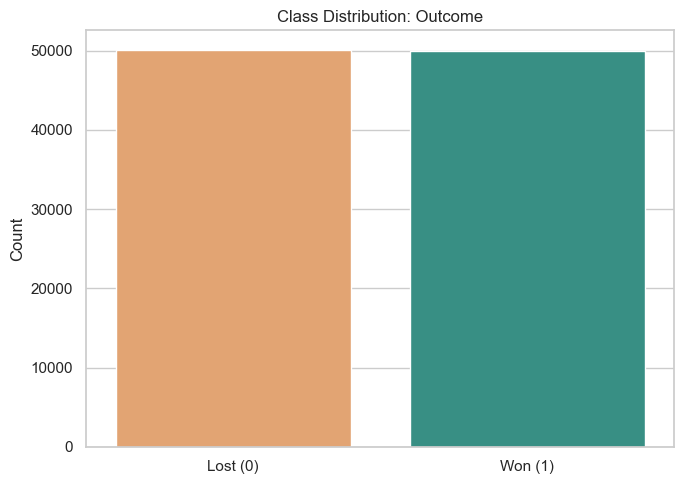

### Insights: Class Imbalance
- Minority class share: **49.93%**; majority share: **50.07%**.
- If imbalance is high, use stratified splits and class-aware metrics (for example, PR-AUC, recall, F1) during modeling.

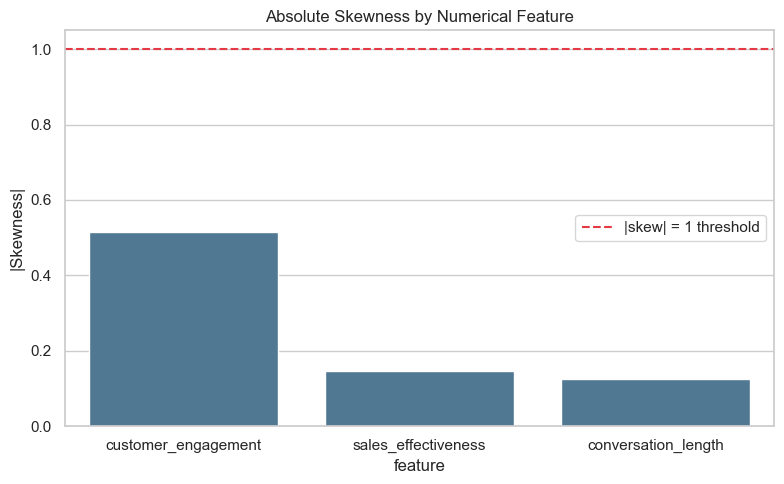

### Insights: Skewed Distributions
- Highly skewed features (|skew| > 1): **None**.
- Strong skew can reduce model stability; consider transformations (for example, log1p) later in feature engineering.

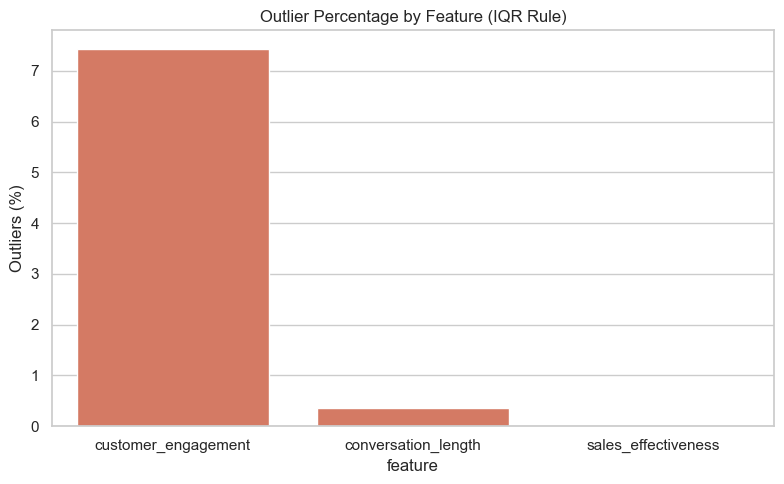

### Insights: Outliers
- Highest outlier burden: **customer_engagement** at **7.42%**.
- Outliers may represent either true high-value opportunities or noisy records; review before trimming or capping.

## EDA Summary
- You now have a complete exploratory view across numeric signals, text behavior, and data-quality risks.
- Use these findings to guide feature engineering and leakage-safe model design in the next phase.

In [9]:
# 3) Risk detection: class imbalance, skewness, and outliers.

# Class imbalance.
class_counts = eda_df["outcome"].value_counts().sort_index()
class_labels = ["Lost (0)", "Won (1)"]
class_values = [int(class_counts.get(0, 0)), int(class_counts.get(1, 0))]

plt.figure(figsize=(7, 5))
sns.barplot(x=class_labels, y=class_values, palette=["#f4a261", "#2a9d8f"])
plt.title("Class Distribution: Outcome")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

total = sum(class_values)
minority_ratio = (min(class_values) / total * 100) if total else 0
majority_ratio = (max(class_values) / total * 100) if total else 0

display(Markdown(
    "### Insights: Class Imbalance\n"
    f"- Minority class share: **{minority_ratio:.2f}%**; majority share: **{majority_ratio:.2f}%**.\n"
    "- If imbalance is high, use stratified splits and class-aware metrics (for example, PR-AUC, recall, F1) during modeling."
))

# Skewness detection.
skew_series = eda_df[numeric_cols].skew().sort_values(key=lambda x: x.abs(), ascending=False)
skew_table = pd.DataFrame({
    "feature": skew_series.index,
    "skew": skew_series.values,
    "abs_skew": skew_series.abs().values,
    "is_skewed_abs_gt_1": skew_series.abs().values > 1,
})

plt.figure(figsize=(8, 5))
sns.barplot(data=skew_table, x="feature", y="abs_skew", color="#457b9d")
plt.axhline(1.0, color="#e63946", linestyle="--", label="|skew| = 1 threshold")
plt.title("Absolute Skewness by Numerical Feature")
plt.ylabel("|Skewness|")
plt.legend()
plt.tight_layout()
plt.show()

highly_skewed = skew_table.loc[skew_table["is_skewed_abs_gt_1"], "feature"].tolist()

display(Markdown(
    "### Insights: Skewed Distributions\n"
    f"- Highly skewed features (|skew| > 1): **{', '.join(highly_skewed) if highly_skewed else 'None'}**.\n"
    "- Strong skew can reduce model stability; consider transformations (for example, log1p) later in feature engineering."
))

# Outlier detection using IQR rule.
outlier_summary = []
for col in numeric_cols:
    q1 = eda_df[col].quantile(0.25)
    q3 = eda_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (eda_df[col] < lower) | (eda_df[col] > upper)
    outlier_count = int(outlier_mask.sum())
    outlier_pct = outlier_count / len(eda_df) * 100 if len(eda_df) else 0

    outlier_summary.append({
        "feature": col,
        "outliers": outlier_count,
        "outlier_pct": outlier_pct,
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=outlier_df, x="feature", y="outlier_pct", color="#e76f51")
plt.title("Outlier Percentage by Feature (IQR Rule)")
plt.ylabel("Outliers (%)")
plt.tight_layout()
plt.show()

most_outlier_feature = outlier_df.iloc[0]

display(Markdown(
    "### Insights: Outliers\n"
    f"- Highest outlier burden: **{most_outlier_feature['feature']}** at **{most_outlier_feature['outlier_pct']:.2f}%**.\n"
    "- Outliers may represent either true high-value opportunities or noisy records; review before trimming or capping."
))

display(Markdown(
    "## EDA Summary\n"
    "- You now have a complete exploratory view across numeric signals, text behavior, and data-quality risks.\n"
    "- Use these findings to guide feature engineering and leakage-safe model design in the next phase."
))

## Feature Engineering for Sales Prediction

This section creates a reusable feature pipeline to produce final modeling inputs:
- **X**: clean feature matrix
- **y**: target vector

Design goals:
- Modular and reusable across training/inference
- Numerically stable preprocessing
- Automatic handling of text as TF-IDF or precomputed embeddings

In [11]:
from IPython.display import Markdown, display

from data_preparation import dataset_to_dataframe, load_hf_dataset
from feature_engineering import (
    FeatureEngineeringConfig,
    SalesFeatureEngineer,
    get_feature_rationale_markdown,
)

# Fallback: recreate cleaned_df if kernel was restarted and variable is missing.
# This keeps the feature engineering section runnable on its own.
if "cleaned_df" not in globals():
    raw_data = load_hf_dataset("DeepMostInnovations/saas-sales-conversations")
    cleaned_df = dataset_to_dataframe(raw_data)

# Configure strategy:
# - "auto" uses embeddings when available, otherwise TF-IDF.
# - set to "tfidf" or "embeddings" explicitly if needed.
fe_config = FeatureEngineeringConfig(text_strategy="auto")
feature_engineer = SalesFeatureEngineer(fe_config)

X, y = feature_engineer.fit_transform(cleaned_df)

display(Markdown(get_feature_rationale_markdown(feature_engineer.get_text_mode())))

print("X type:", type(X))
print("X shape:", X.shape)
print("y type:", type(y))
print("y shape:", y.shape)
print("Text mode used:", feature_engineer.get_text_mode())
print("Feature count:", len(feature_engineer.get_feature_names()))

# Keep feature names accessible for inspection.
feature_names = feature_engineer.get_feature_names()
feature_names[:20]

### Why These Features Are Created
- **engagement_per_length**: Captures engagement density, not just raw engagement.
- **effectiveness_per_length**: Measures sales effectiveness normalized by conversation size.
- **engagement_x_effectiveness**: Models interaction where strong engagement and effectiveness together can amplify conversion probability.
- **Categorical one-hot features**: Preserve segment-level information (for example, channel or region) without imposing fake ordinal relationships.
- **Text features (precomputed embeddings)**: Convert conversation language into machine-usable signals for intent, objections, urgency, and buying cues.
- **Standard scaling on numeric block**: Brings numeric features to comparable scale for stable optimization and fair regularization impact.

X type: <class 'scipy.sparse._csr.csr_matrix'>
X shape: (100000, 3187)
y type: <class 'pandas.Series'>
y shape: (100000,)
Text mode used: embeddings
Feature count: 3187


['customer_engagement',
 'sales_effectiveness',
 'conversation_length',
 'engagement_per_length',
 'effectiveness_per_length',
 'engagement_x_effectiveness',
 'company_id_saas-0',
 'company_id_saas-1',
 'company_id_saas-10',
 'company_id_saas-11',
 'company_id_saas-12',
 'company_id_saas-13',
 'company_id_saas-14',
 'company_id_saas-15',
 'company_id_saas-16',
 'company_id_saas-17',
 'company_id_saas-18',
 'company_id_saas-19',
 'company_id_saas-2',
 'company_id_saas-3']

## Baseline Model: Logistic Regression

Why use Logistic Regression as a baseline:
- It is **simple and interpretable**, so it helps validate whether engineered features carry predictive signal.
- It trains quickly on high-dimensional sparse features (such as TF-IDF/embeddings + one-hot).
- Coefficients provide a transparent first view of feature influence direction.
- It sets a clean benchmark before trying more complex models.

This baseline is intentionally lightweight: train/test split, core classification metrics, and confusion matrix.

Baseline Logistic Regression Metrics
Accuracy : 0.9816
Precision: 0.9834
Recall   : 0.9797
F1-score : 0.9815

Confusion Matrix:
[[9849  165]
 [ 203 9783]]


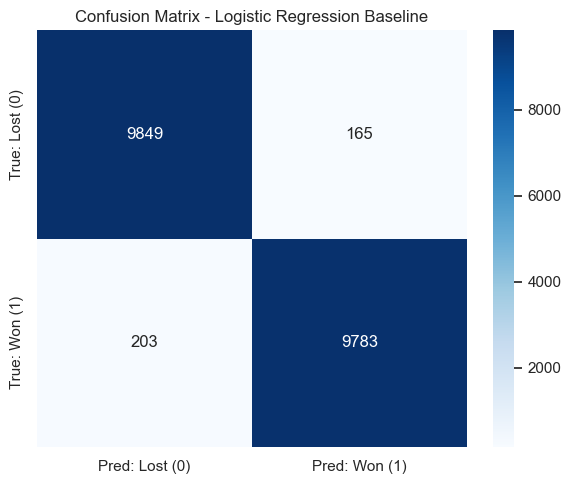

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

# Ensure engineered features are available.
if "X" not in globals() or "y" not in globals():
    raise ValueError("X and y are not available. Run the feature engineering cell first.")

# 1) Train/test split (stratified to preserve class balance).
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 2) Baseline model.
log_reg = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
log_reg.fit(X_train, y_train)

# 3) Predictions + evaluation metrics.
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Baseline Logistic Regression Metrics")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# 4) Confusion matrix.
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: Lost (0)", "Pred: Won (1)"],
    yticklabels=["True: Lost (0)", "True: Won (1)"],
)
plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.tight_layout()
plt.show()